In [50]:
# Import dan konfigurasi
%matplotlib inline

import cv2
import numpy as np
import os
import time
from collections import defaultdict
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Sesuaikan path dataset (relatif terhadap notebook di folder assignment)
DATASET_PATH = os.path.join('..', 'dataset')
OBJECTS = ['ceramic', 'mouse', 'mug', 'tupperware', 'zymuno']
REF_IMAGE_NAME = '1.jpeg'
MAX_TEST_IMAGES = 5

# Cek ketersediaan SURF
SURF_AVAILABLE = True
try:
    _ = cv2.xfeatures2d.SURF_create(400)
except:
    SURF_AVAILABLE = False
    print("⚠️  SURF tidak tersedia. Hanya menggunakan SIFT dan ORB.")

⚠️  SURF tidak tersedia. Hanya menggunakan SIFT dan ORB.


In [51]:
# Fungsi-fungsi utama
def ekstrak_fitur(gambar, algoritma='SIFT'):
    gray = cv2.cvtColor(gambar, cv2.COLOR_BGR2GRAY)
    if algoritma == 'SIFT':
        detektor = cv2.SIFT_create()
    elif algoritma == 'SURF':
        if not SURF_AVAILABLE:
            raise RuntimeError("SURF tidak tersedia")
        detektor = cv2.xfeatures2d.SURF_create(400)
    elif algoritma == 'ORB':
        detektor = cv2.ORB_create()
    else:
        raise ValueError("Algoritma tidak dikenal")
    t0 = time.time()
    kp, des = detektor.detectAndCompute(gray, None)
    dt = time.time() - t0
    dim = des.shape[1] if des is not None else 0
    return kp, des, dt, dim

def cocokkan_fitur(des1, des2, algoritma='SIFT', metode='BF', ambang_rasio=0.75):
    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return [], [], 0.0
    t0 = time.time()
    if metode == 'BF':
        norm = cv2.NORM_HAMMING if algoritma == 'ORB' else cv2.NORM_L2
        bf = cv2.BFMatcher(norm, crossCheck=False)
        pasangan_mentah = bf.knnMatch(des1, des2, k=2)
    elif metode == 'FLANN':
        if algoritma == 'ORB':
            index_params = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
        else:
            index_params = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        pasangan_mentah = flann.knnMatch(des1, des2, k=2)
    else:
        raise ValueError("Metode harus BF atau FLANN")
    
    baik = []
    for match_pair in pasangan_mentah:
        if len(match_pair) == 2:          # <--- PERBAIKAN DI SINI
            m, n = match_pair
            if m.distance < ambang_rasio * n.distance:
                baik.append(m)
    dt = time.time() - t0
    return pasangan_mentah, baik, dt

def cari_homografi(kp1, kp2, pasangan_baik, ambang_reproj=5.0):
    if len(pasangan_baik) < 4:
        return None, 0, False, None
    src_pts = np.float32([kp1[m.queryIdx].pt for m in pasangan_baik]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in pasangan_baik]).reshape(-1,1,2)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ambang_reproj)
    if H is not None:
        inlier = np.sum(mask)
        return H, inlier, True, mask.ravel().astype(bool)
    else:
        return None, 0, False, None

def tampilkan_gambar(img_bgr, judul=""):
    """Tampilkan gambar OpenCV (BGR) di notebook."""
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(judul)
    plt.axis('off')
    plt.show()

In [52]:
# 1. Memuat dataset
print("="*70)
print("LANGKAH 1: Memuat dataset...")
dataset = {}
for obj in OBJECTS:
    folder = os.path.join(DATASET_PATH, obj)
    if not os.path.exists(folder):
        continue
    ref_path = os.path.join(folder, REF_IMAGE_NAME)
    ref_img = cv2.imread(ref_path)
    if ref_img is None:
        continue
    test_imgs = []
    for i in range(2, 2+MAX_TEST_IMAGES):
        fname = f"{i}.jpeg"
        tpath = os.path.join(folder, fname)
        if os.path.exists(tpath):
            img = cv2.imread(tpath)
            if img is not None:
                test_imgs.append((fname, img))
    dataset[obj] = {'ref': ref_img, 'ref_path': ref_path, 'tests': test_imgs}
    print(f"  {obj}: referensi + {len(test_imgs)} citra uji")

LANGKAH 1: Memuat dataset...
  ceramic: referensi + 5 citra uji
  mouse: referensi + 5 citra uji
  mug: referensi + 5 citra uji
  tupperware: referensi + 5 citra uji
  zymuno: referensi + 5 citra uji



LANGKAH 2: Ekstraksi fitur dan visualisasi keypoints...


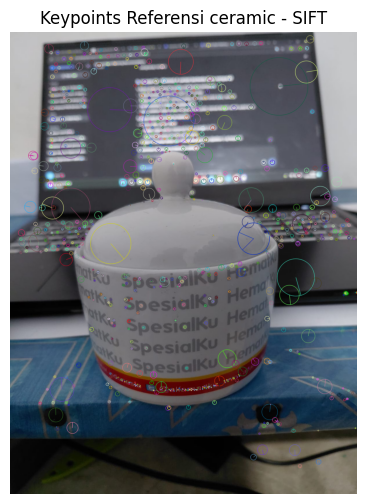

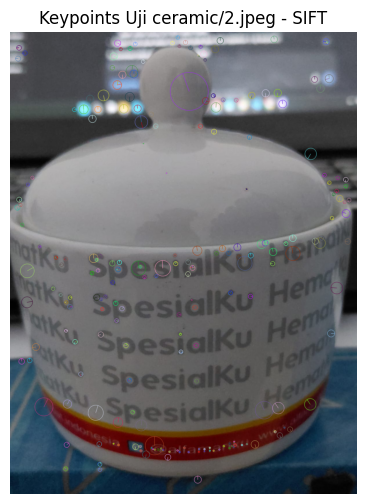

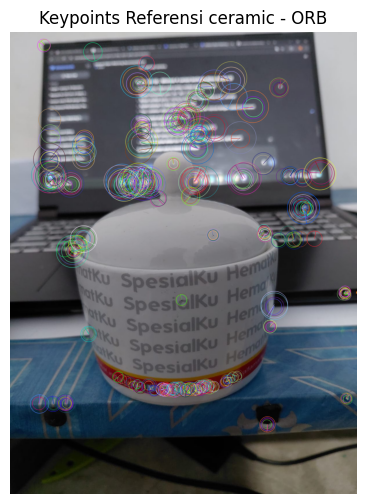

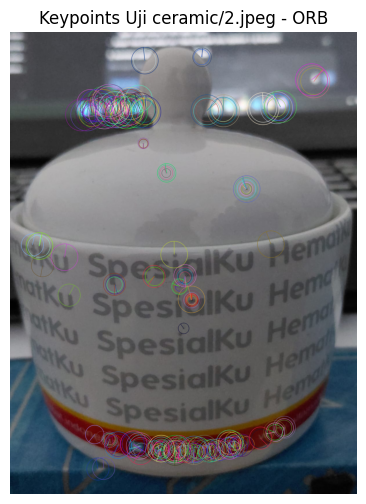

In [53]:
# 2. Ekstraksi fitur dan visualisasi keypoints
print("\n" + "="*70)
print("LANGKAH 2: Ekstraksi fitur dan visualisasi keypoints...")
algoritma_list = ['SIFT', 'ORB']
if SURF_AVAILABLE:
    algoritma_list.insert(1, 'SURF')

cache_fitur = {}
for obj, data in dataset.items():
    # referensi
    kunci = (obj, 'ref', REF_IMAGE_NAME)
    cache_fitur[kunci] = {}
    for alg in algoritma_list:
        try:
            kp, des, dt, dim = ekstrak_fitur(data['ref'], alg)
            cache_fitur[kunci][alg] = {'kp': kp, 'des': des, 'waktu': dt, 'n_kp': len(kp) if kp else 0, 'dim': dim}
        except Exception as e:
            print(f"  Error {obj}/ref {alg}: {e}")
            cache_fitur[kunci][alg] = None
    # uji
    for fname, img in data['tests']:
        kunci = (obj, 'test', fname)
        cache_fitur[kunci] = {}
        for alg in algoritma_list:
            try:
                kp, des, dt, dim = ekstrak_fitur(img, alg)
                cache_fitur[kunci][alg] = {'kp': kp, 'des': des, 'waktu': dt, 'n_kp': len(kp) if kp else 0, 'dim': dim}
            except Exception as e:
                print(f"  Error {obj}/{fname} {alg}: {e}")
                cache_fitur[kunci][alg] = None

# Visualisasi keypoints untuk objek pertama (referensi dan satu citra uji)
obj_contoh = OBJECTS[0]
ref_img = dataset[obj_contoh]['ref']
uji_contoh = dataset[obj_contoh]['tests'][0] if dataset[obj_contoh]['tests'] else None
if uji_contoh:
    uji_name, uji_img = uji_contoh
else:
    uji_name, uji_img = None, None

for alg in algoritma_list:
    # Gambar keypoints referensi
    kp_ref = cache_fitur[(obj_contoh, 'ref', REF_IMAGE_NAME)][alg]['kp']
    img_kp_ref = cv2.drawKeypoints(ref_img, kp_ref, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    tampilkan_gambar(img_kp_ref, f"Keypoints Referensi {obj_contoh} - {alg}")
    
    if uji_img is not None:
        kp_uji = cache_fitur[(obj_contoh, 'test', uji_name)][alg]['kp']
        img_kp_uji = cv2.drawKeypoints(uji_img, kp_uji, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        tampilkan_gambar(img_kp_uji, f"Keypoints Uji {obj_contoh}/{uji_name} - {alg}")


LANGKAH 3: Pencocokan fitur dan visualisasi inlier/outlier...


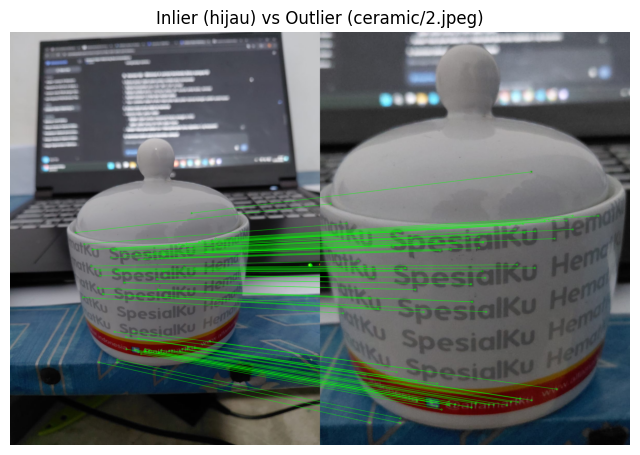

Pencocokan: 100 kombinasi, sukses 98


In [54]:
# 3. Feature matching dan visualisasi inlier/outlier
print("\n" + "="*70)
print("LANGKAH 3: Pencocokan fitur dan visualisasi inlier/outlier...")
AMBANG_RASIO = 0.75
AMBANG_REPROJ = 5.0
hasil_matching = []

for obj, data in dataset.items():
    ref_kp_des = {}
    for alg in algoritma_list:
        cache_ref = cache_fitur[(obj, 'ref', REF_IMAGE_NAME)][alg]
        if cache_ref and cache_ref['des'] is not None:
            ref_kp_des[alg] = (cache_ref['kp'], cache_ref['des'])
    for fname, _ in data['tests']:
        for alg in algoritma_list:
            if alg not in ref_kp_des:
                continue
            cache_test = cache_fitur[(obj, 'test', fname)][alg]
            if not cache_test or cache_test['des'] is None:
                continue
            kp1, des1 = ref_kp_des[alg]
            kp2, des2 = cache_test['kp'], cache_test['des']
            for metode in ['BF', 'FLANN']:
                try:
                    mentah, baik, waktu_cocok = cocokkan_fitur(des1, des2, alg, metode, AMBANG_RASIO)
                    H, inlier, sukses, mask = cari_homografi(kp1, kp2, baik, AMBANG_REPROJ)
                    hasil_matching.append({
                        'obj': obj, 'uji': fname, 'algoritma': alg, 'metode': metode,
                        'pasangan_mentah': len(mentah), 'pasangan_baik': len(baik),
                        'inlier': inlier, 'waktu': waktu_cocok, 'sukses': sukses,
                        'kp1': kp1, 'kp2': kp2, 'matches_baik': baik, 'mask_inlier': mask
                    })
                except Exception as e:
                    print(f"  Error matching {obj}/{fname} {alg} {metode}: {e}")

# Visualisasi satu pasangan sukses (SIFT+BF jika ada)
visual = None
for r in hasil_matching:
    if r['sukses'] and r['algoritma']=='SIFT' and r['metode']=='BF':
        visual = r
        break
if visual is None:
    visual = next((r for r in hasil_matching if r['sukses']), None)

if visual:
    kp1 = visual['kp1']
    kp2 = visual['kp2']
    matches = visual['matches_baik']
    mask_inlier = visual['mask_inlier']
    # Gambar semua good matches dengan warna hijau (inlier) dan merah (outlier)
    draw_params = dict(matchColor=(0,255,0), singlePointColor=None, matchesMask=mask_inlier.astype(int).tolist(), flags=2)
    img_ref = dataset[visual['obj']]['ref']
    img_uji = None
    for fname, img in dataset[visual['obj']]['tests']:
        if fname == visual['uji']:
            img_uji = img
            break
    if img_uji is not None:
        img_match = cv2.drawMatches(img_ref, kp1, img_uji, kp2, matches, None, **draw_params)
        tampilkan_gambar(img_match, f"Inlier (hijau) vs Outlier ({visual['obj']}/{visual['uji']})")

print(f"Pencocokan: {len(hasil_matching)} kombinasi, sukses {sum(1 for r in hasil_matching if r['sukses'])}")


LANGKAH 4: BoVW dan grafik pengaruh ukuran vocabulary...
  k= 10: SVM acc=0.40, k-NN acc=0.50
  k= 20: SVM acc=0.50, k-NN acc=0.30
  k= 50: SVM acc=0.80, k-NN acc=0.70
  k=100: SVM acc=0.70, k-NN acc=0.70


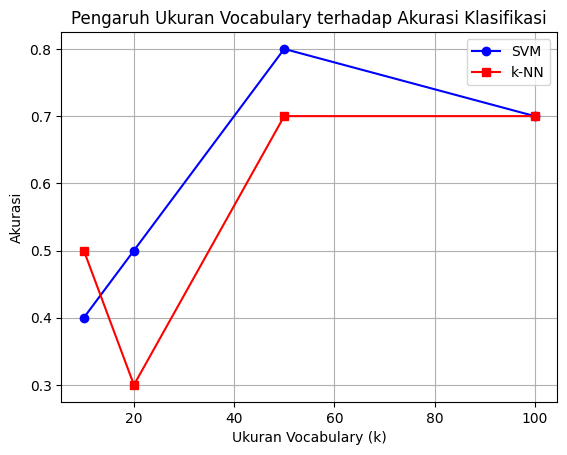

In [55]:
# 4. Bag of Visual Words (BoVW) + grafik pengaruh k
print("\n" + "="*70)
print("LANGKAH 4: BoVW dan grafik pengaruh ukuran vocabulary...")
JUMLAH_LATIH = 3
citra_latih = {}
citra_uji = {}
for obj, data in dataset.items():
    daftar_latih = [(REF_IMAGE_NAME, data['ref'])]
    daftar_uji = []
    for i, (fname, img) in enumerate(data['tests']):
        if i < JUMLAH_LATIH:
            daftar_latih.append((fname, img))
        else:
            daftar_uji.append((fname, img))
    citra_latih[obj] = daftar_latih
    citra_uji[obj] = daftar_uji

BOVW_ALG = 'SIFT'
semua_des_latih = []
for obj in OBJECTS:
    for fname, img in citra_latih[obj]:
        kunci = (obj, 'ref' if fname==REF_IMAGE_NAME else 'test', fname)
        if cache_fitur.get(kunci, {}).get(BOVW_ALG) and cache_fitur[kunci][BOVW_ALG]['des'] is not None:
            des = cache_fitur[kunci][BOVW_ALG]['des']
            semua_des_latih.append(des)
        else:
            kp, des, _, _ = ekstrak_fitur(img, BOVW_ALG)
            if des is not None:
                semua_des_latih.append(des)
semua_des_latih = np.vstack(semua_des_latih)

nilai_k = [10, 20, 50, 100]
kamus = {}
for k in nilai_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(semua_des_latih)
    kamus[k] = kmeans.cluster_centers_.astype(np.float32)

def ambil_descriptor(obj, fname):
    kunci = (obj, 'ref' if fname==REF_IMAGE_NAME else 'test', fname)
    if kunci in cache_fitur and cache_fitur[kunci].get(BOVW_ALG) and cache_fitur[kunci][BOVW_ALG]['des'] is not None:
        return cache_fitur[kunci][BOVW_ALG]['des']
    else:
        folder = os.path.join(DATASET_PATH, obj)
        img = cv2.imread(os.path.join(folder, fname))
        if img is None:
            return None
        kp, des, _, _ = ekstrak_fitur(img, BOVW_ALG)
        return des

def histogram_bow(des, vocab):
    if des is None or len(des) == 0:
        return np.zeros(len(vocab), dtype=np.float32)
    dists = np.linalg.norm(des[:, np.newaxis] - vocab, axis=2)
    idx = np.argmin(dists, axis=1)
    hist = np.zeros(len(vocab))
    np.add.at(hist, idx, 1)
    return hist / (np.sum(hist) + 1e-7)

label_encoder = LabelEncoder().fit(OBJECTS)
akurasi_svm_list = []
akurasi_knn_list = []
for k in nilai_k:
    vocab = kamus[k]
    X_tr, y_tr = [], []
    for obj in OBJECTS:
        for fname, _ in citra_latih[obj]:
            X_tr.append(histogram_bow(ambil_descriptor(obj, fname), vocab))
            y_tr.append(obj)
    X_tr = np.array(X_tr, dtype=np.float32)
    y_tr = label_encoder.transform(y_tr)
    X_te, y_te = [], []
    for obj in OBJECTS:
        for fname, _ in citra_uji[obj]:
            X_te.append(histogram_bow(ambil_descriptor(obj, fname), vocab))
            y_te.append(obj)
    X_te = np.array(X_te, dtype=np.float32)
    y_te = label_encoder.transform(y_te)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    svm = SVC(kernel='linear', C=1, random_state=42).fit(X_tr_s, y_tr)
    knn = KNeighborsClassifier(n_neighbors=3).fit(X_tr_s, y_tr)
    acc_svm = accuracy_score(y_te, svm.predict(X_te_s))
    acc_knn = accuracy_score(y_te, knn.predict(X_te_s))
    akurasi_svm_list.append(acc_svm)
    akurasi_knn_list.append(acc_knn)
    print(f"  k={k:3d}: SVM acc={acc_svm:.2f}, k-NN acc={acc_knn:.2f}")

# Grafik pengaruh vocabulary
plt.figure()
plt.plot(nilai_k, akurasi_svm_list, 'bo-', label='SVM')
plt.plot(nilai_k, akurasi_knn_list, 'rs-', label='k-NN')
plt.xlabel('Ukuran Vocabulary (k)')
plt.ylabel('Akurasi')
plt.title('Pengaruh Ukuran Vocabulary terhadap Akurasi Klasifikasi')
plt.legend()
plt.grid(True)
plt.show()


LANGKAH 5: PCA dan grafik pengaruhnya...
  PCA dim= 16: rata-rata inlier=100.40 dari 25 pasangan
  PCA dim= 32: rata-rata inlier=105.52 dari 25 pasangan
  PCA dim= 64: rata-rata inlier=106.44 dari 25 pasangan
  PCA dim=128: rata-rata inlier=106.84 dari 25 pasangan


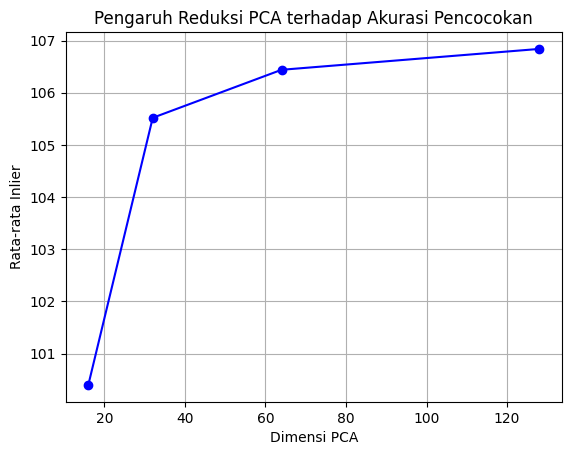

In [56]:
# 5. PCA + grafik pengaruh dimensi
print("\n" + "="*70)
print("LANGKAH 5: PCA dan grafik pengaruhnya...")
DIMENSI_PCA = [16, 32, 64, 128]
semua_des_sift = []
peta_descriptor = {}
for obj in OBJECTS:
    kunci_ref = (obj, 'ref', REF_IMAGE_NAME)
    if cache_fitur[kunci_ref].get('SIFT') and cache_fitur[kunci_ref]['SIFT']['des'] is not None:
        des = cache_fitur[kunci_ref]['SIFT']['des']
        semua_des_sift.append(des)
        peta_descriptor[(obj, REF_IMAGE_NAME)] = des
    for fname, _ in dataset[obj]['tests']:
        kunci = (obj, 'test', fname)
        if cache_fitur.get(kunci, {}).get('SIFT') and cache_fitur[kunci]['SIFT']['des'] is not None:
            des = cache_fitur[kunci]['SIFT']['des']
            semua_des_sift.append(des)
            peta_descriptor[(obj, fname)] = des

semua_des_sift = np.vstack(semua_des_sift)
pca = PCA(n_components=128).fit(semua_des_sift)
hasil_pca = {}
for d in DIMENSI_PCA:
    W = pca.components_[:d].T
    desk_pca = {k: np.dot(v, W).astype(np.float32) for k, v in peta_descriptor.items()}
    total_inlier = 0
    total_pasangan = 0
    for obj in OBJECTS:
        ref_pca = desk_pca.get((obj, REF_IMAGE_NAME))
        if ref_pca is None:
            continue
        kp_ref = cache_fitur[(obj, 'ref', REF_IMAGE_NAME)]['SIFT']['kp']
        for fname, _ in dataset[obj]['tests']:
            test_pca = desk_pca.get((obj, fname))
            if test_pca is None:
                continue
            kp_test = cache_fitur[(obj, 'test', fname)]['SIFT']['kp']
            _, baik, _ = cocokkan_fitur(ref_pca, test_pca, 'SIFT', 'BF', AMBANG_RASIO)
            _, inlier, sukses, _ = cari_homografi(kp_ref, kp_test, baik, AMBANG_REPROJ)
            if sukses:
                total_inlier += inlier
                total_pasangan += 1
    rata_inlier = total_inlier / total_pasangan if total_pasangan else 0
    hasil_pca[d] = rata_inlier
    print(f"  PCA dim={d:3d}: rata-rata inlier={rata_inlier:.2f} dari {total_pasangan} pasangan")

# Grafik PCA
plt.figure()
plt.plot(DIMENSI_PCA, [hasil_pca[d] for d in DIMENSI_PCA], 'bo-')
plt.xlabel('Dimensi PCA')
plt.ylabel('Rata-rata Inlier')
plt.title('Pengaruh Reduksi PCA terhadap Akurasi Pencocokan')
plt.grid(True)
plt.show()


LANGKAH 6: Evaluasi menyeluruh...

--- Tabel Perbandingan Metode Matching ---
Metode          Rata Inlier  Rata Waktu   Tingkat Sukses
SIFT+BF         106.8        4.2          ms 100.00%     
SIFT+FLANN      106.5        28.1         ms 100.00%     
ORB+BF          24.3         0.8          ms 92.00%      
ORB+FLANN       23.8         2.5          ms 100.00%     


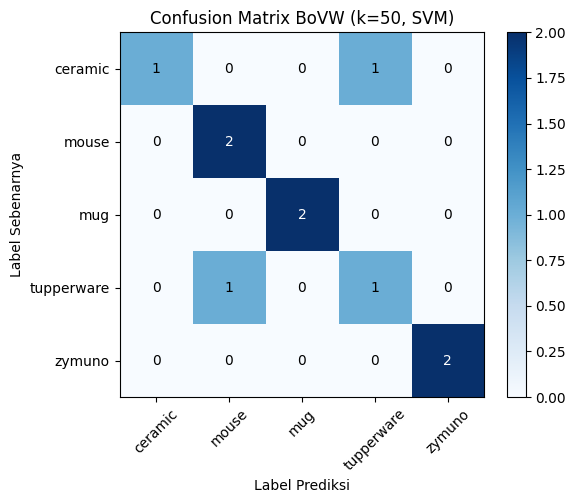


--- Kurva Precision-Recall (contoh) ---


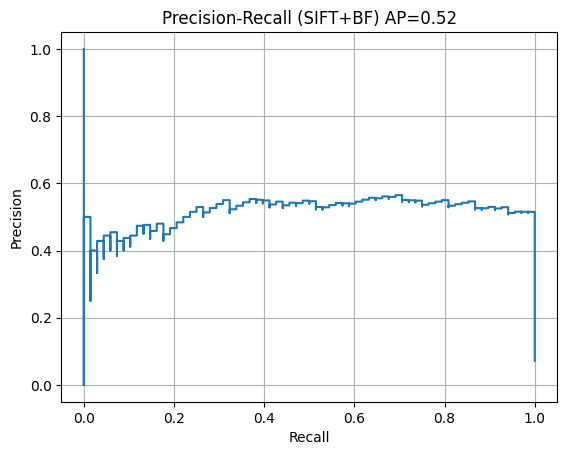


Semua langkah selesai.


In [57]:
# 6. Evaluasi menyeluruh (tabel, confusion matrix, PR curve)
print("\n" + "="*70)
print("LANGKAH 6: Evaluasi menyeluruh...")

# Tabel perbandingan metode matching
agregat = defaultdict(list)
for r in hasil_matching:
    agregat[(r['algoritma'], r['metode'])].append(r)

print("\n--- Tabel Perbandingan Metode Matching ---")
print(f"{'Metode':<15} {'Rata Inlier':<12} {'Rata Waktu':<12} {'Tingkat Sukses':<12}")
for (alg, met), entries in agregat.items():
    avg_inl = np.mean([e['inlier'] for e in entries if e['sukses']])
    avg_time = np.mean([e['waktu'] for e in entries])
    success = np.mean([e['sukses'] for e in entries])
    print(f"{alg+'+'+met:<15} {avg_inl:<12.1f} {avg_time*1000:<12.1f} ms {success:<12.2%}")

# Confusion matrix dari BoVW (k terbaik SVM)
k_terbaik = nilai_k[np.argmax(akurasi_svm_list)]
vocab_terbaik = kamus[k_terbaik]
X_te_best = []
y_te_best = []
for obj in OBJECTS:
    for fname, _ in citra_uji[obj]:
        X_te_best.append(histogram_bow(ambil_descriptor(obj, fname), vocab_terbaik))
        y_te_best.append(obj)
X_te_best = np.array(X_te_best, dtype=np.float32)
y_te_best = label_encoder.transform(y_te_best)
scaler = StandardScaler()
X_tr_best = []
y_tr_best = []
for obj in OBJECTS:
    for fname, _ in citra_latih[obj]:
        X_tr_best.append(histogram_bow(ambil_descriptor(obj, fname), vocab_terbaik))
        y_tr_best.append(obj)
X_tr_best = scaler.fit_transform(np.array(X_tr_best, dtype=np.float32))
y_tr_best = label_encoder.transform(y_tr_best)
svm_best = SVC(kernel='linear', C=1, random_state=42).fit(X_tr_best, y_tr_best)
y_pred_best = svm_best.predict(scaler.transform(X_te_best))
cm = confusion_matrix(y_te_best, y_pred_best)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix BoVW (k={k_terbaik}, SVM)')
plt.colorbar()
tick_marks = np.arange(len(OBJECTS))
plt.xticks(tick_marks, OBJECTS, rotation=45)
plt.yticks(tick_marks, OBJECTS)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black")
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

# Kurva Precision-Recall (contoh SIFT+BF)
print("\n--- Kurva Precision-Recall (contoh) ---")
obj_contoh = OBJECTS[0]
if dataset[obj_contoh]['tests']:
    uji_contoh = dataset[obj_contoh]['tests'][0][0]
    kp1 = cache_fitur[(obj_contoh, 'ref', REF_IMAGE_NAME)]['SIFT']['kp']
    des1 = cache_fitur[(obj_contoh, 'ref', REF_IMAGE_NAME)]['SIFT']['des']
    kp2 = cache_fitur[(obj_contoh, 'test', uji_contoh)]['SIFT']['kp']
    des2 = cache_fitur[(obj_contoh, 'test', uji_contoh)]['SIFT']['des']
    if des1 is not None and des2 is not None:
        bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
        mentah_knn = bf.knnMatch(des1, des2, k=2)
        pasangan = []
        rasio = []
        for m,n in mentah_knn:
            if n.distance > 0:
                pasangan.append((m,n))
                rasio.append(m.distance / n.distance)
        rasio = np.array(rasio)
        acuan_baik = [m for m,n in pasangan if m.distance < 0.65*n.distance]
        H_ref, inl_ref, _, mask_ref = cari_homografi(kp1, kp2, acuan_baik, 3.0)
        if mask_ref is not None and inl_ref > 0:
            inlier_set = set()
            for i, m in enumerate(acuan_baik):
                if mask_ref[i]:
                    inlier_set.add((m.queryIdx, m.trainIdx))
            y_true = np.array([1 if (m.queryIdx, m.trainIdx) in inlier_set else 0 for m,n in pasangan])
            y_score = np.array([1.0 - m.distance/(n.distance+1e-7) for m,n in pasangan])
            pres, rec, _ = precision_recall_curve(y_true, y_score)
            ap = average_precision_score(y_true, y_score)
            plt.figure()
            plt.step(rec, pres, where='post')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall (SIFT+BF) AP={ap:.2f}')
            plt.grid(True)
            plt.show()
        else:
            print("  Referensi inlier tidak ditemukan untuk PR curve.")
    else:
        print("  Descriptor tidak lengkap untuk PR curve.")
else:
    print("  Tidak ada citra uji untuk PR curve.")

print("\nSemua langkah selesai.")